# H2D2 (H-alpha / D-alpha) spectroscopy pipeline

Thin driver around `pipeline.py`. Validate on **one spectrum** first, then run all files and pool them.

Stages: load -> calibrate (optional) -> crop to the doublet -> fit two Gaussians + linear background -> read off line centers.

**Model** (all knobs live in `pipeline.CONFIG`):
$$I(\lambda)=B+m\lambda+A_H e^{-\frac{(\lambda-\lambda_H)^2}{2\sigma_H^2}}+A_D e^{-\frac{(\lambda-\lambda_D)^2}{2\sigma_D^2}}$$

From the fit we extract $\lambda_H$, $\lambda_D$, and the separation $\Delta\lambda=\lambda_H-\lambda_D$. The single-pixel maximum is a poor line center at this resolution, so we fit; and a constant calibration offset cancels in $\Delta\lambda$, so the **separation** is the robust quantity to report (per the handout).

In [1]:
import importlib
import pipeline
importlib.reload(pipeline)  # re-run this cell after editing pipeline.py
from pipeline import (CONFIG, run_pipeline, load_spectrum, crop, fit_spectrum,
                      plot_spectrum, plot_fit, plot_combined, combine_runs,
                      list_runs, two_gaussian)

# Show inline in the notebook in addition to saving PNGs
%matplotlib inline
CONFIG["show"] = True

## Config toggles
Adjust here, then re-run the cells below.

In [2]:
# ===================== DATASET =====================
CONFIG["data_root"] = "H2D2 Data"      # folder of HR4C2500 spectra (Trial 1..7)
CONFIG["save_dir"]  = "H2D2 Processed Outputs"

# --- fit window (nm): tight enough to exclude stray lines, wide enough for bg
CONFIG["fit_window"] = (654.5, 656.4)

# --- initial guesses / bounds for the two-Gaussian fit
CONFIG["fit"].update(sigma_guess=0.07, sigma_min=0.01, sigma_max=0.30)

# --- optional linear wavelength calibration  wl -> offset + scale*wl
#     A pure offset cancels in Delta lambda, so leave this off unless you have
#     derived (offset, scale) from the Neon Calibration Data.
CONFIG["calibration"].update(enabled=False, offset=0.0, scale=1.0)

# --- literature reference (annotation only)
CONFIG["lambda_H_lit"], CONFIG["lambda_D_lit"], CONFIG["dlambda_lit"] = 656.279, 656.100, 0.179

print("runs found:")
for r in list_runs():
    print(" ", r)

runs found:
  H2D2 Data\Trial 1.txt
  H2D2 Data\Trial 2.txt
  H2D2 Data\Trial 3.txt
  H2D2 Data\Trial 4.txt
  H2D2 Data\Trial 5.txt
  H2D2 Data\Trial 6.txt
  H2D2 Data\Trial 7.txt


## 1-4. Single spectrum: load, crop, fit
Validate the window and fit on one file before running them all.

loaded 3648 points, 629.7-680.2 nm


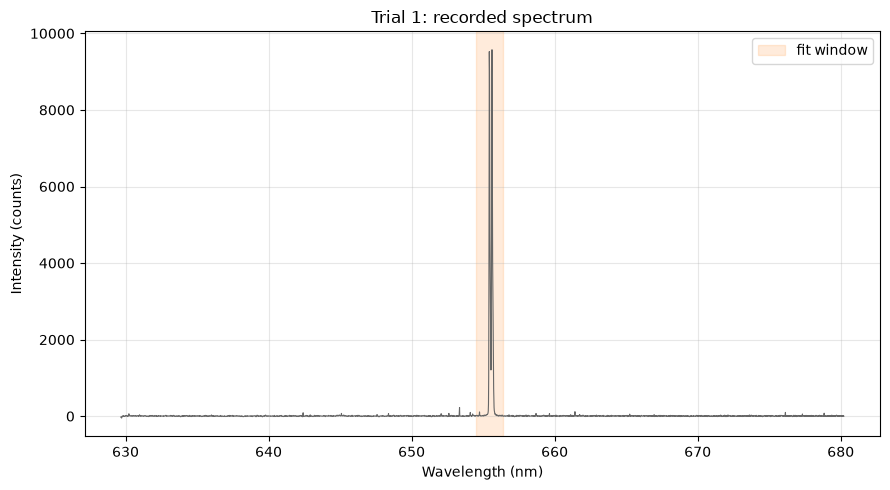

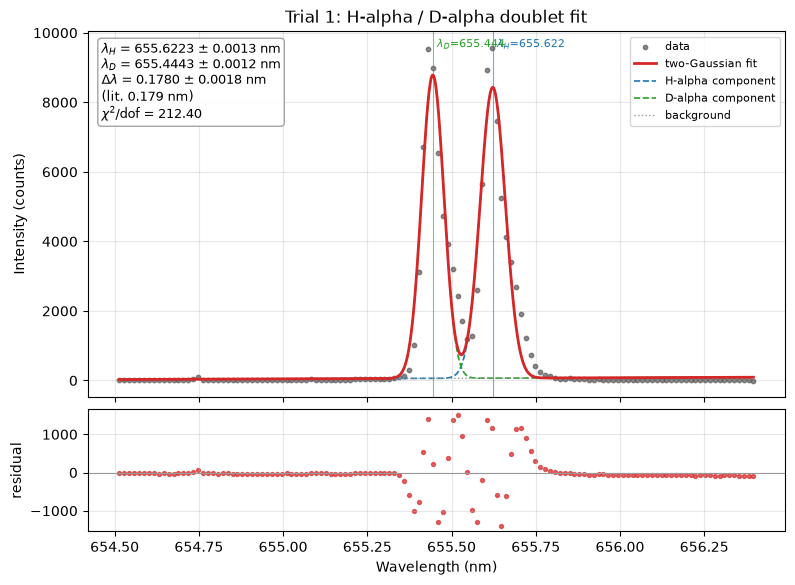

Run: Trial 1
  fit window       : 654.514 - 656.396 nm (131 pts)
  converged        : True   chi2/dof = 212.40
  lambda_H (H-alpha): 655.6223 +/- 0.0013 nm
  lambda_D (D-alpha): 655.4443 +/- 0.0012 nm
  Delta lambda      : 0.1780 +/- 0.0018 nm
  peak widths sigma : H 0.0372 nm,  D 0.0329 nm


In [3]:
RUN = list_runs()[0]          # or paste a specific filename / path
df = load_spectrum(RUN)
print(f"loaded {len(df)} points, {df['wavelength'].min():.1f}-{df['wavelength'].max():.1f} nm")

_ = plot_spectrum(df, RUN)    # full spectrum, fit window shaded
res = fit_spectrum(df, RUN)   # crop + two-Gaussian fit
_ = plot_fit(res)             # data + fit + components + residuals
print(res.summary())

## All runs
Run the full pipeline on every spectrum (writes `H2D2 Processed Outputs/<trial>/1_spectrum.png`, `2_fit.png`). Inline display is suppressed here to avoid flooding the notebook with figures — re-open the PNGs from the folders.

In [4]:
_show = CONFIG["show"]; CONFIG["show"] = False
results = {}
for r in list_runs():
    res = run_pipeline(r, plots=True)
    results[res.run] = res
CONFIG["show"] = _show

print(f"{'run':28s} {'lambda_H':>10s} {'lambda_D':>10s} {'Delta lambda (nm)':>20s} {'chi2/dof':>9s}")
for name, r in results.items():
    print(f"{name:28s} {r.lambda_H:10.4f} {r.lambda_D:10.4f} "
          f"  {r.dlambda:.4f} +/- {r.dlambda_err:.4f}   {r.chi2_dof:8.1f}")

run                            lambda_H   lambda_D    Delta lambda (nm)  chi2/dof
Trial 1                        655.6223   655.4443   0.1780 +/- 0.0018      212.4
Trial 2                        655.6224   655.4447   0.1777 +/- 0.0018      225.1
Trial 3                        655.6223   655.4447   0.1776 +/- 0.0018      238.7
Trial 4                        655.6222   655.4443   0.1778 +/- 0.0018      232.5
Trial 5                        655.6220   655.4441   0.1779 +/- 0.0018      231.0
Trial 6                        655.6222   655.4445   0.1777 +/- 0.0018      232.4
Trial 7                        655.6225   655.4446   0.1780 +/- 0.0018      233.5


## Combined result
Pool the per-run fits. $\Delta\lambda$ is combined by inverse-variance weighting (Birge-inflated when runs scatter more than their fit errors predict); the plain mean / standard error are shown for comparison.

Combined over 7 runs:
  lambda_H     = 655.6223 +/- 0.0005 nm
  lambda_D     = 655.4444 +/- 0.0005 nm
  Delta lambda = 0.1778 +/- 0.0007 nm   (weighted, Birge)
               = 0.1778 +/- 0.0001 nm   (plain mean +/- SEM)
  run-to-run scatter (std) = 0.0001 nm
  literature Delta lambda  = 0.179 nm


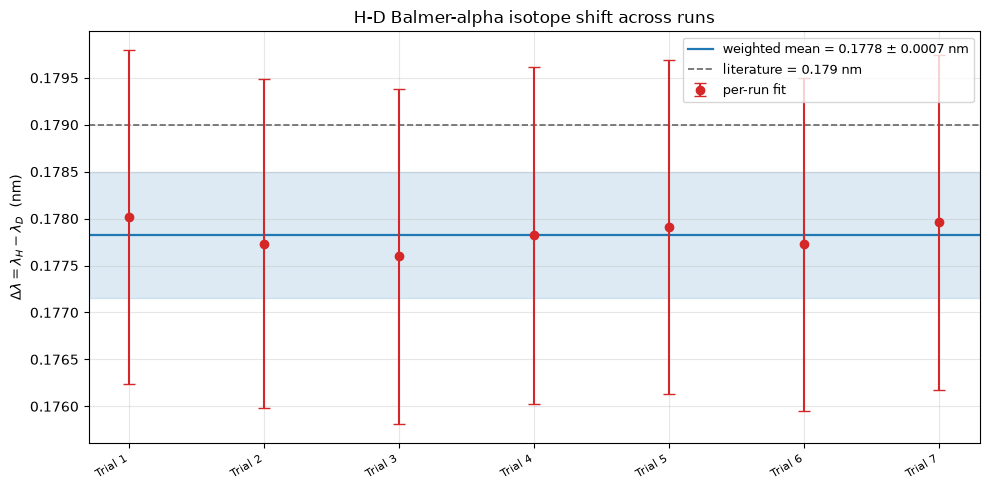

In [5]:
comb = combine_runs(results)
print(f"Combined over {comb['n_runs']} runs:")
print(f"  lambda_H     = {comb['lambda_H']:.4f} +/- {comb['lambda_H_err']:.4f} nm")
print(f"  lambda_D     = {comb['lambda_D']:.4f} +/- {comb['lambda_D_err']:.4f} nm")
print(f"  Delta lambda = {comb['dlambda']:.4f} +/- {comb['dlambda_err']:.4f} nm   (weighted, Birge)")
print(f"               = {comb['dlambda_mean']:.4f} +/- {comb['dlambda_sem']:.4f} nm   (plain mean +/- SEM)")
print(f"  run-to-run scatter (std) = {comb['dlambda_std']:.4f} nm")
print(f"  literature Delta lambda  = {CONFIG['dlambda_lit']:.3f} nm")

_ = plot_combined(results)    # Delta lambda per run + weighted-mean band